In [2]:
%load_ext autoreload
%autoreload 2
%pdb on

Automatic pdb calling has been turned ON


In [3]:
import importlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

from camels_tools import analyze_halos,load_snapshot,plot_theory_predictions
from camels_tools import from_file
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import os
import pandas as pd
import dmh_tools
%matplotlib ipympl
from glob import glob
ROOT_PATH = os.getcwd() + '/../'

# Do the stacking, 
Write to .h5

In [14]:
M_star_cen = np.geomspace(1e9,1e11,num = 13)
all_results_all_b = []
all_bmin = [0.12,0.16,0.20]
for nnn in ['090','088','086','084','082']:
    filepaths = glob(os.path.join(ROOT_PATH,'data_products','camels_data','20250414',f'*snap{nnn}_haloDM.csv'))
    for filepath in filepaths:    
        num_halos = 40
        M_200_min = 0
        M_200_max = np.inf
        sfr_min = 0.1
        sfr_max = 100.0
        sim_df = load_snapshot(filepath)
        #print('Input:',filepath)
        for b_min,color in zip(all_bmin,cm.inferno(np.linspace(0, 0.5, len(all_bmin)))):
            out_path = os.path.join(ROOT_PATH,'data_products','camels_stack',os.path.split(filepath)[-1][:-4] + f'_b={b_min:.2f}.h5')
            results, stack = analyze_halos(
                filepath = filepath,
                df = sim_df,
                num_halos=10,
                b_min=0.1,
                b_max=b_min,
                M_200_min=M_200_min,
                M_200_max=M_200_max,
                M_star_range = M_star_cen,
                width_factor = 2,
                sfr_min=sfr_min,
                sfr_max=sfr_max,
                out_file=out_path
            )
            #if (results['weighted_std'] < 50).any():
                #print(stack)
            #print('Output:',out_path)

Not enough halos after filtering (bin index=11). Found 6, but requested 10.
sightlines within halos: 34, unique halos: 6, sampled sightlines: 6
Not enough halos after filtering (bin index=12). Found 4, but requested 10.
sightlines within halos: 23, unique halos: 4, sampled sightlines: 4
Not enough halos after filtering (bin index=11). Found 6, but requested 10.
sightlines within halos: 143, unique halos: 6, sampled sightlines: 6
Not enough halos after filtering (bin index=12). Found 4, but requested 10.
sightlines within halos: 104, unique halos: 4, sampled sightlines: 4
Not enough halos after filtering (bin index=11). Found 6, but requested 10.
sightlines within halos: 271, unique halos: 6, sampled sightlines: 6
Not enough halos after filtering (bin index=12). Found 4, but requested 10.
sightlines within halos: 196, unique halos: 4, sampled sightlines: 4
Not enough halos after filtering (bin index=12). Found 5, but requested 10.
sightlines within halos: 23, unique halos: 5, sampled si

# Load observational data
from .csv, and load the stacks from .h5

In [60]:
_df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
_df.set_index('name',inplace=True)
keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df) * dmh_tools.not_low_dm(_df)
df = _df[keep]


In [61]:
import camels_tools

In [62]:
df.index

Index(['FRB20190608B', 'FRB20200430A', 'FRB20171020A', 'FRB20201124A',
       'FRB20211127I', 'FRB20211212A', 'FRB20210807D', 'FRB20201124A',
       'FRB20220912A', 'FRB20220725A', 'FRB20230526A', 'FRB20230708A',
       'FRB20231226A', 'FRB20240210A', 'FRB20220319D', 'FRB20220207C',
       'FRB20200223B', 'FRB20230222B', 'FRB20230311A', 'FRB20230926A',
       'FRB20231011A', 'FRB20231123A', 'FRB20231128A', 'FRB20231201A',
       'FRB20231223C', 'FRB20231229A', 'FRB20231230A'],
      dtype='object', name='name')

In [63]:
np.where(df.index == 'FRB20210807D')

(array([6]),)

In [64]:
dmh_tools.sigma_tot(df)

name
FRB20190608B     71.086005
FRB20200430A     88.723034
FRB20171020A     11.111043
FRB20201124A     68.056255
FRB20211127I     30.878956
FRB20211212A     45.918295
FRB20210807D     79.266569
FRB20201124A     68.027407
FRB20220912A     54.853399
FRB20220725A    101.933140
FRB20230526A     87.224217
FRB20230708A     65.703862
FRB20231226A     87.185630
FRB20240210A     16.091872
FRB20220319D     28.837074
FRB20220207C     31.207364
FRB20200223B     39.181435
FRB20230222B     67.681658
FRB20230311A    103.105399
FRB20230926A     36.552669
FRB20231011A     51.522288
FRB20231123A     49.513817
FRB20231128A     66.769230
FRB20231201A     72.554243
FRB20231223C     66.444122
FRB20231229A     16.734594
FRB20231230A     22.532840
Name: DM_NE2001, dtype: float64

Still needs M* measurement: Index(['FRB20201124A', 'FRB20220912A', 'FRB20220725A', 'FRB20230526A',
       'FRB20230708A', 'FRB20231226A', 'FRB20240210A', 'FRB20230222B',
       'FRB20230311A', 'FRB20230926A', 'FRB20231011A', 'FRB20231123A',
       'FRB20231128A', 'FRB20231201A', 'FRB20231223C', 'FRB20231229A',
       'FRB20231230A'],
      dtype='object', name='name')
Still needs M* measurement: Index(['FRB20201124A', 'FRB20220912A', 'FRB20220725A', 'FRB20230526A',
       'FRB20230708A', 'FRB20231226A', 'FRB20240210A', 'FRB20230222B',
       'FRB20230311A', 'FRB20230926A', 'FRB20231011A', 'FRB20231123A',
       'FRB20231128A', 'FRB20231201A', 'FRB20231223C', 'FRB20231229A',
       'FRB20231230A'],
      dtype='object', name='name')
Still needs M* measurement: Index(['FRB20201124A', 'FRB20220912A', 'FRB20220725A', 'FRB20230526A',
       'FRB20230708A', 'FRB20231226A', 'FRB20240210A', 'FRB20230222B',
       'FRB20230311A', 'FRB20230926A', 'FRB20231011A', 'FRB20231123A',
       'FRB202311

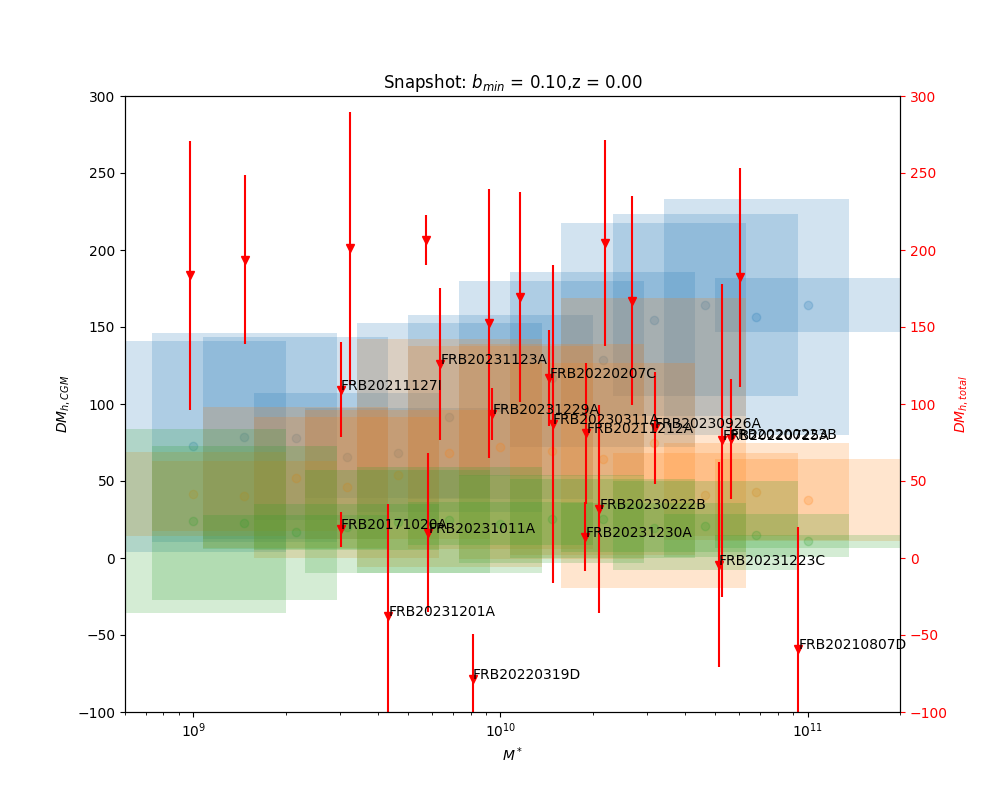

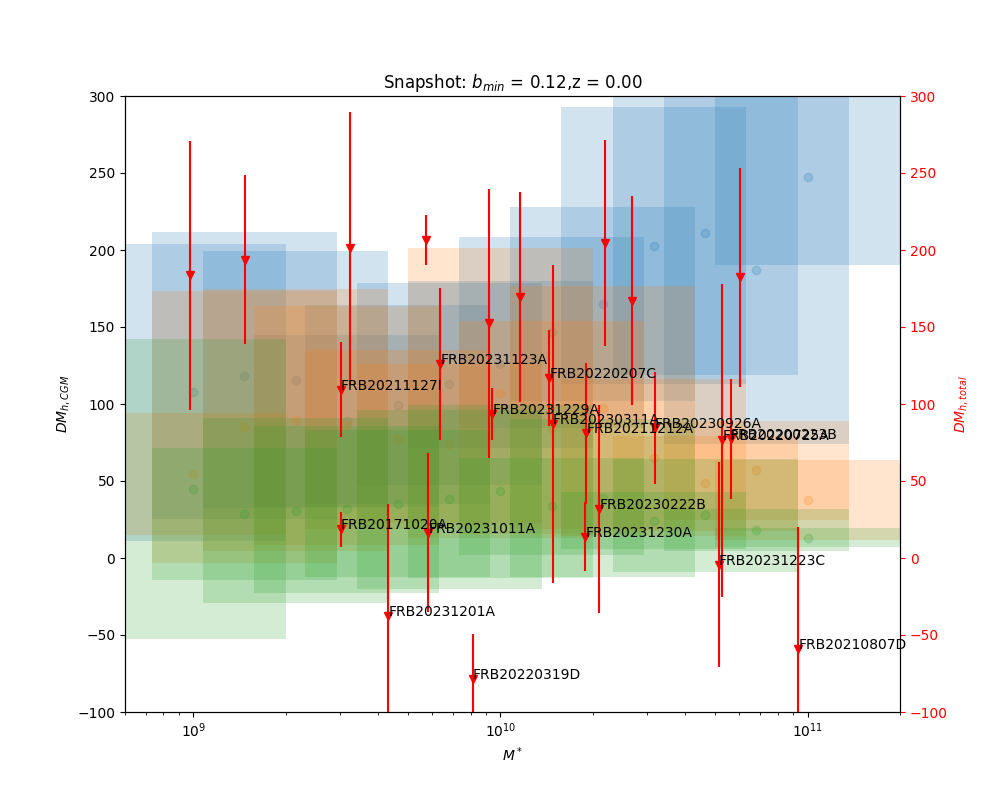

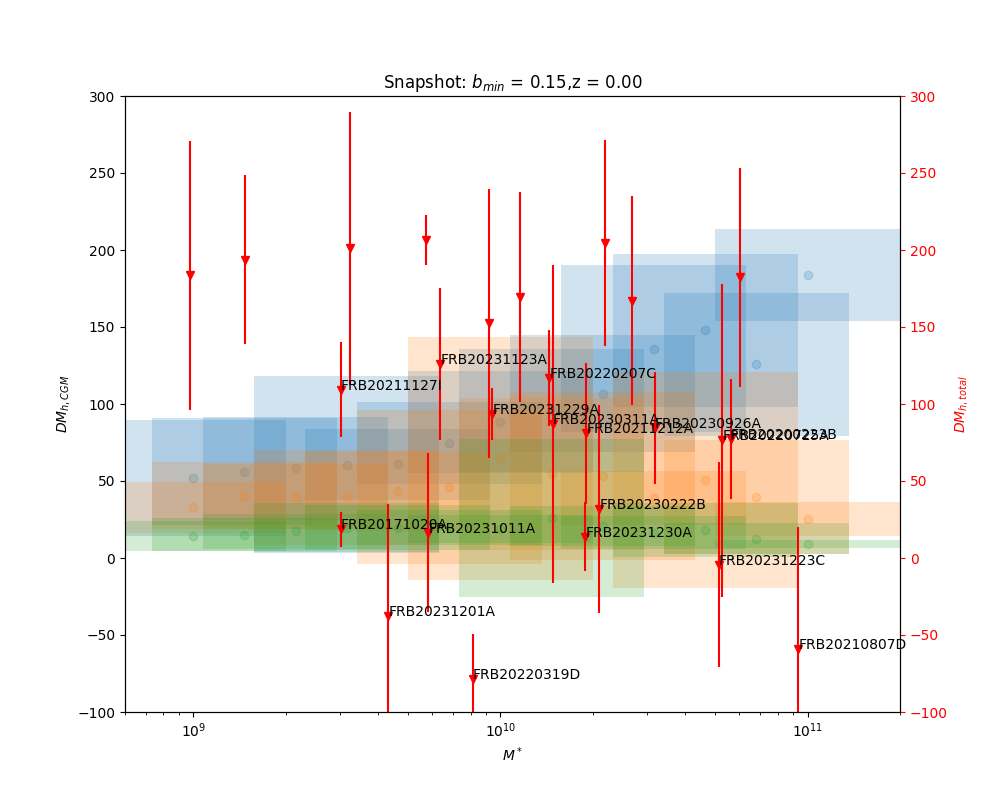

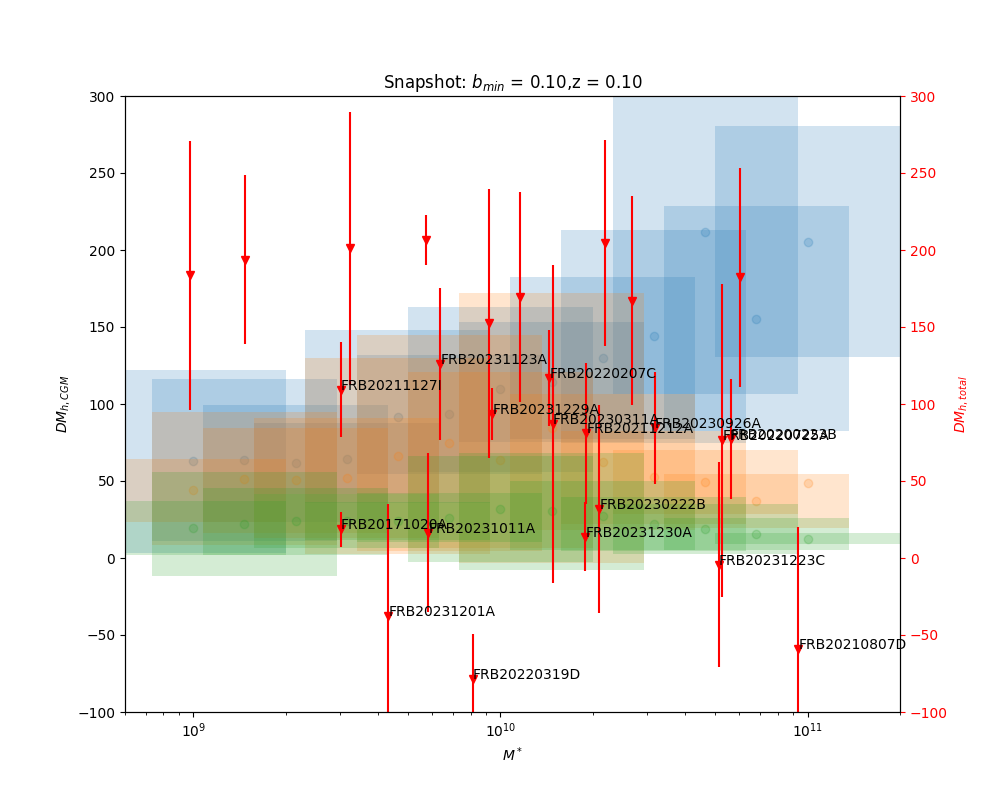

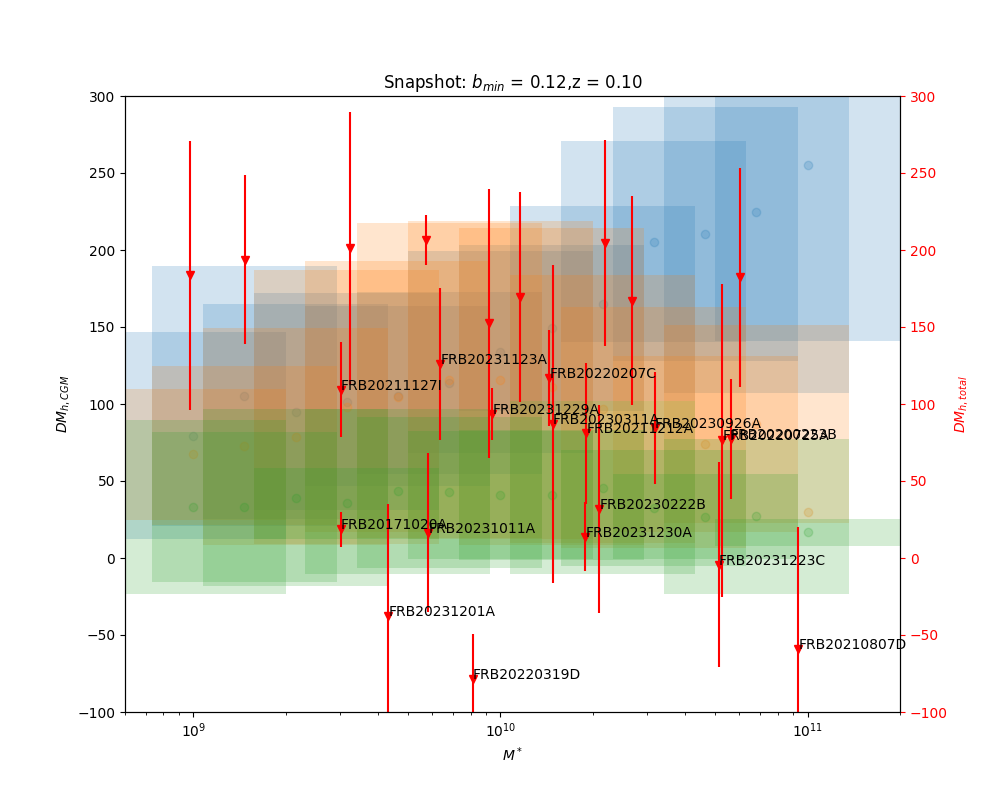

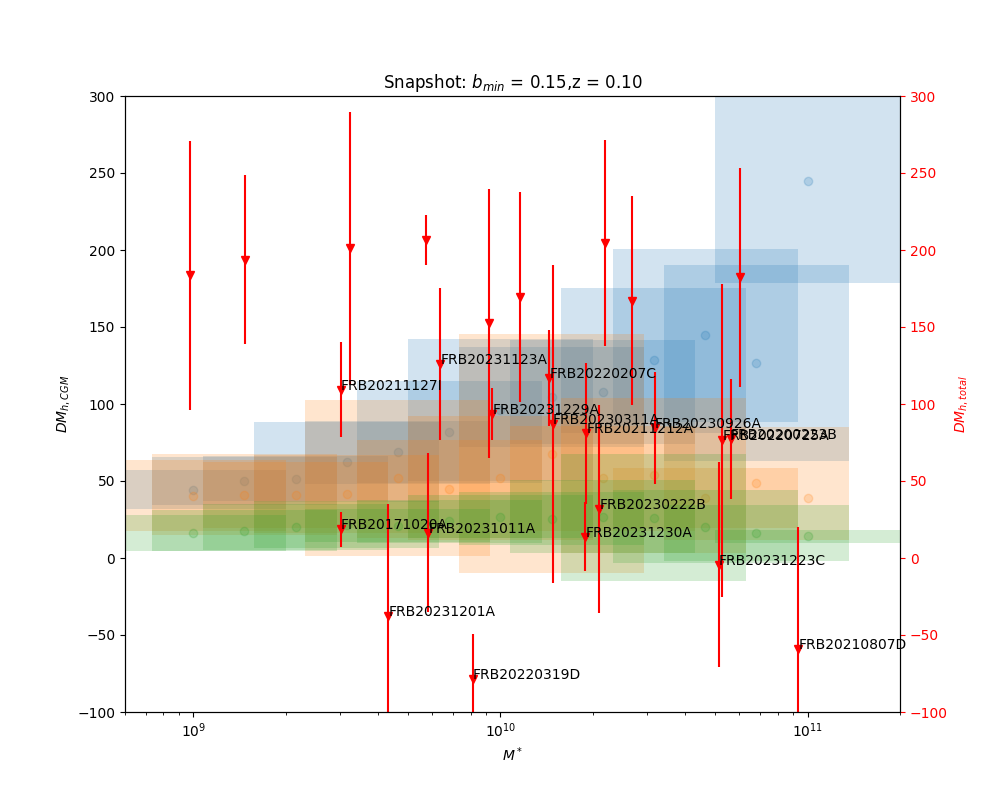

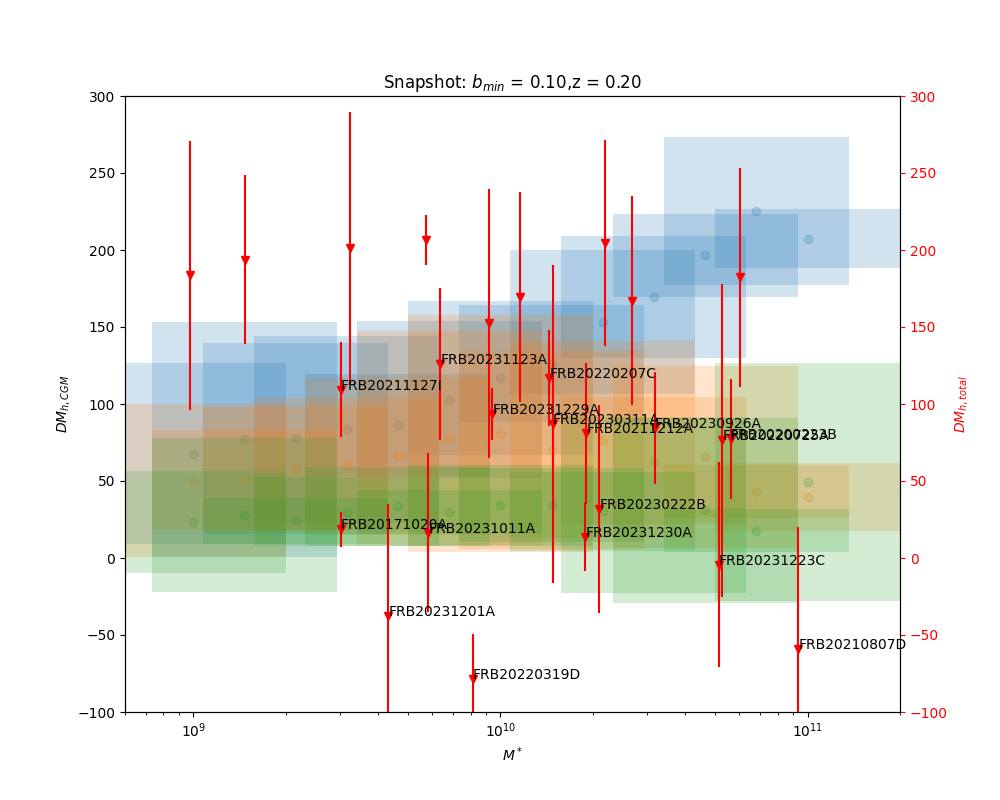

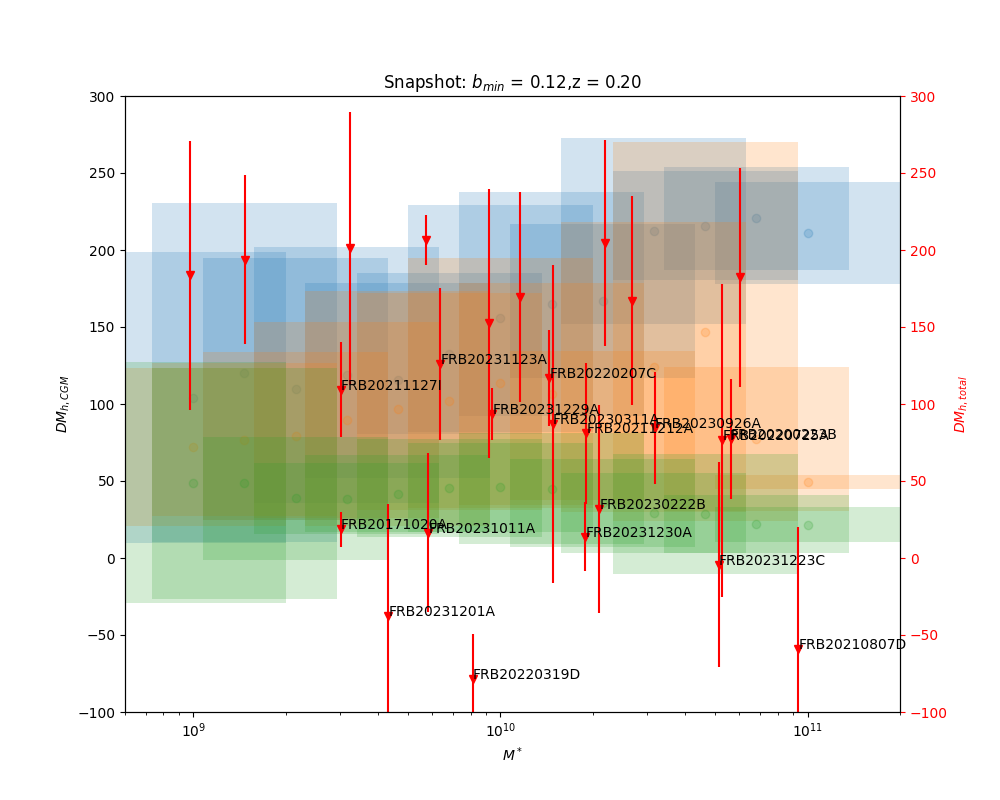

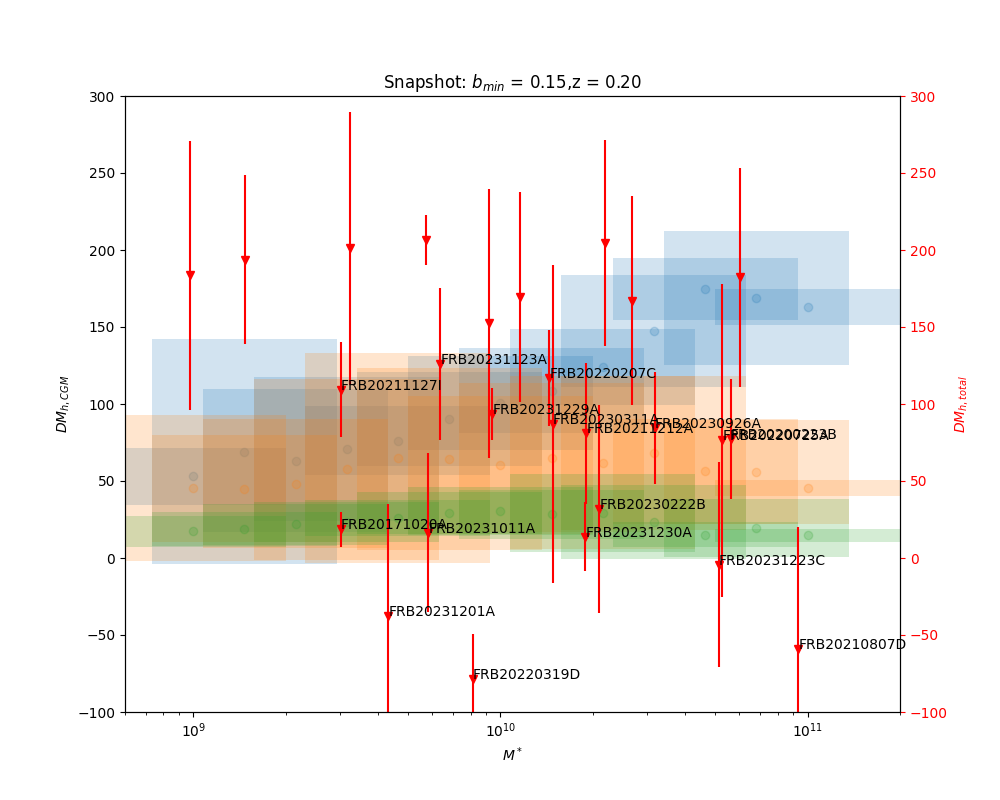

In [98]:
cm.inferno(np.linspace(0, 0.5, 3))
for snap_id in ['090','086','082']:
    snap_z = camels_tools.CAMELS_REDSHIFTS[snap_id]
    for bb in [0.1,0.12,0.15]:
        plt.figure(figsize = (10,8))
        res = camels_tools.plot_theory_predictions(f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/Astrid_1P_3_0_snap{snap_id}_haloDM_b={bb:.2f}.h5',
                        ax = plt.gca(),alpha = 0.2,facecolor = 'C0')
        res = camels_tools.plot_theory_predictions(f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/IllustrisTNG_1P_3_0_snap{snap_id}_haloDM_b={bb:.2f}.h5',
                        ax = plt.gca(),alpha = 0.2,facecolor = 'C1')
        res = camels_tools.plot_theory_predictions(f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/SIMBA_1P_3_0_snap{snap_id}_haloDM_b={bb:.2f}.h5',
                        ax = plt.gca(),alpha = 0.2,facecolor = 'C2')


        plot_mstar = 10**dmh_tools.best_stellar_mass(df)
        plot_dm = df['DM_host_restframe']
        plot_dmerr = dmh_tools.sigma_tot(df)
        plt.errorbar(x = plot_mstar,y = plot_dm,yerr = plot_dmerr, linestyle = 'none',marker = 'v',color = 'red')
        
        plt.xscale('log')
        plt.xlim(6e8,2e11)
        plt.ylim(-100,300)
        plt.xlabel(r'$M^*$')
        plt.ylabel(r'$DM_{h,CGM}$',color = 'black')
        
        ax2 = plt.gca().twinx()
        ax2.set_ylabel(r'$DM_{h,total}$',color = 'red')
        ax2.tick_params(axis='y', colors='red')
        ax2.set_ylim(-100,300)
        snap_str = r'$b_{min}$ = ' + f'{bb:.2f},z = {snap_z:.2f}'
        plt.title(r'Snapshot: ' + snap_str)
        plt.savefig(f'/Users/calvinleung/kko_host_paper/figures/msdm_{bb:.2f}_{snap_id}.pdf',dpi = 110,bbox_inches='tight')
        for ii, ms, dm in zip(np.arange(plot_mstar.size),plot_mstar,plot_dm):
            if dm < 150:
                plt.text(ms,dm,s = df.index[ii])

In [67]:
from scipy.special import erf

def log_likelihood(ms,dm,dm_err,res,weight_index = 0,verbose = False):
    """Computes log likelihood

    Returns an array whose shape is the same as ms."""
    
    bin_centers = np.sqrt(res['M_star_bins'][:,0] *res['M_star_bins'][:,1])
    indices = np.zeros_like(ms,dtype = int)
    for ii,_ms in enumerate(ms):
        indices[ii] = np.argmin(np.abs(bin_centers - _ms))
    model = res['weighted_mean'][weight_index,[indices]].squeeze() # fix model weighting scheme, then choose correct bin to compare each data point against
    model_err = res['weighted_std'][weight_index,[indices]].squeeze() # fix model weighting scheme, then choose correct bin to compare each data point against
    argument = (dm - model) / np.sqrt(model_err**2 + dm_err**2) # argument of the erf. Likelihood large (model allowed) when argument > 0
    indices_weird = np.where(argument < -5)
    print('DOuble check these:',indices_weird)
    if verbose:
        print(argument)
    log_ell = np.log(0.5 * (1 + erf(argument)))
    return log_ell
    
    

In [68]:
log_likelihoods_per_burst = np.zeros((3,3,3,len(plot_dm)))
for iimodel, model in enumerate(['SIMBA','IllustrisTNG','ASTRID']):
    for iiz, snap_id in enumerate(['090','086','082']):
        snap_z = camels_tools.CAMELS_REDSHIFTS[snap_id]
        for iibb,bb in enumerate([0.1,0.12,0.15]):
            stack_path = f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/{model}_1P_3_0_snap{snap_id}_haloDM_b={bb:.2f}.h5'
            results = from_file(stack_path)
            log_likelihoods_per_burst[iimodel, iiz, iibb,:] = log_likelihood(plot_mstar,plot_dm,plot_dmerr,results,verbose = True)

DOuble check these: (array([], dtype=int64),)
name
FRB20190608B    1.998234
FRB20200430A    1.721183
FRB20171020A   -0.678775
FRB20201124A    1.696044
FRB20211127I    1.617656
FRB20211212A    0.434999
FRB20210807D   -1.014354
FRB20201124A    1.696668
FRB20220912A    1.293525
FRB20220725A    0.294099
FRB20230526A    0.917337
FRB20230708A    1.718195
FRB20231226A    1.174170
FRB20240210A    2.316277
FRB20220319D   -1.703600
FRB20220207C    1.012205
FRB20200223B    0.507705
FRB20230222B   -0.225527
FRB20230311A    0.305691
FRB20230926A    0.921420
FRB20231011A   -0.381968
FRB20231123A    0.898988
FRB20231128A    1.824637
FRB20231201A   -0.856683
FRB20231223C   -0.524111
FRB20231229A    1.494892
FRB20231230A   -0.663729
dtype: float64
DOuble check these: (array([], dtype=int64),)
name
FRB20190608B    1.922612
FRB20200430A    0.981517
FRB20171020A   -0.412232
FRB20201124A    1.531892
FRB20211127I    0.406123
FRB20211212A    0.031798
FRB20210807D   -1.064306
FRB20201124A    0.630412
FRB20220

In [81]:
fake_logl = log_likelihood(plot_mstar,plot_dm,plot_dmerr,fake_results,verbose = True)

DOuble check these: (array([], dtype=int64),)
name
FRB20190608B    1.625008
FRB20200430A    1.560494
FRB20171020A    0.197035
FRB20201124A    1.674771
FRB20211127I    1.110875
FRB20211212A    1.203076
FRB20210807D   -0.717260
FRB20201124A    1.861155
FRB20220912A    1.239083
FRB20220725A    0.695683
FRB20230526A    1.937905
FRB20230708A    3.745513
FRB20231226A    1.434143
FRB20240210A    4.334886
FRB20220319D   -1.161709
FRB20220207C    1.830882
FRB20200223B    1.370891
FRB20230222B    0.381304
FRB20230311A    0.742455
FRB20230926A    1.033381
FRB20231011A    0.205640
FRB20231123A    1.602549
FRB20231128A    2.467018
FRB20231201A   -0.439840
FRB20231223C   -0.054285
FRB20231229A    1.487825
FRB20231230A    0.256396
dtype: float64


/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_43598/3567561039.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.linspace(-10,10),np.log(0.5 * (1 + erf(np.linspace(-10,10)))))


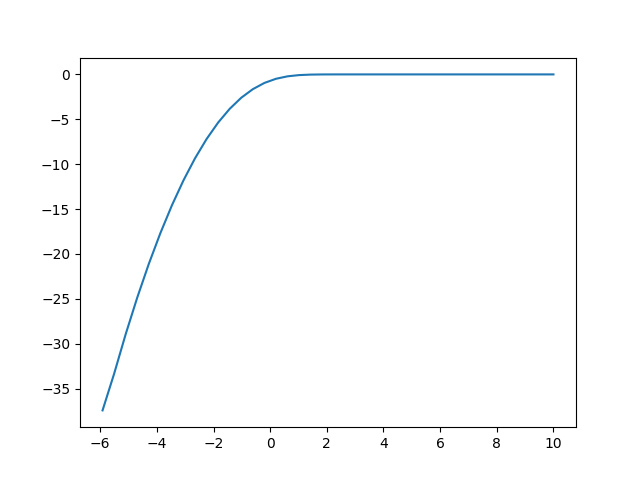

In [69]:
plt.figure()
plt.plot(np.linspace(-10,10),np.log(0.5 * (1 + erf(np.linspace(-10,10)))))

# Check burst by burst for outliers

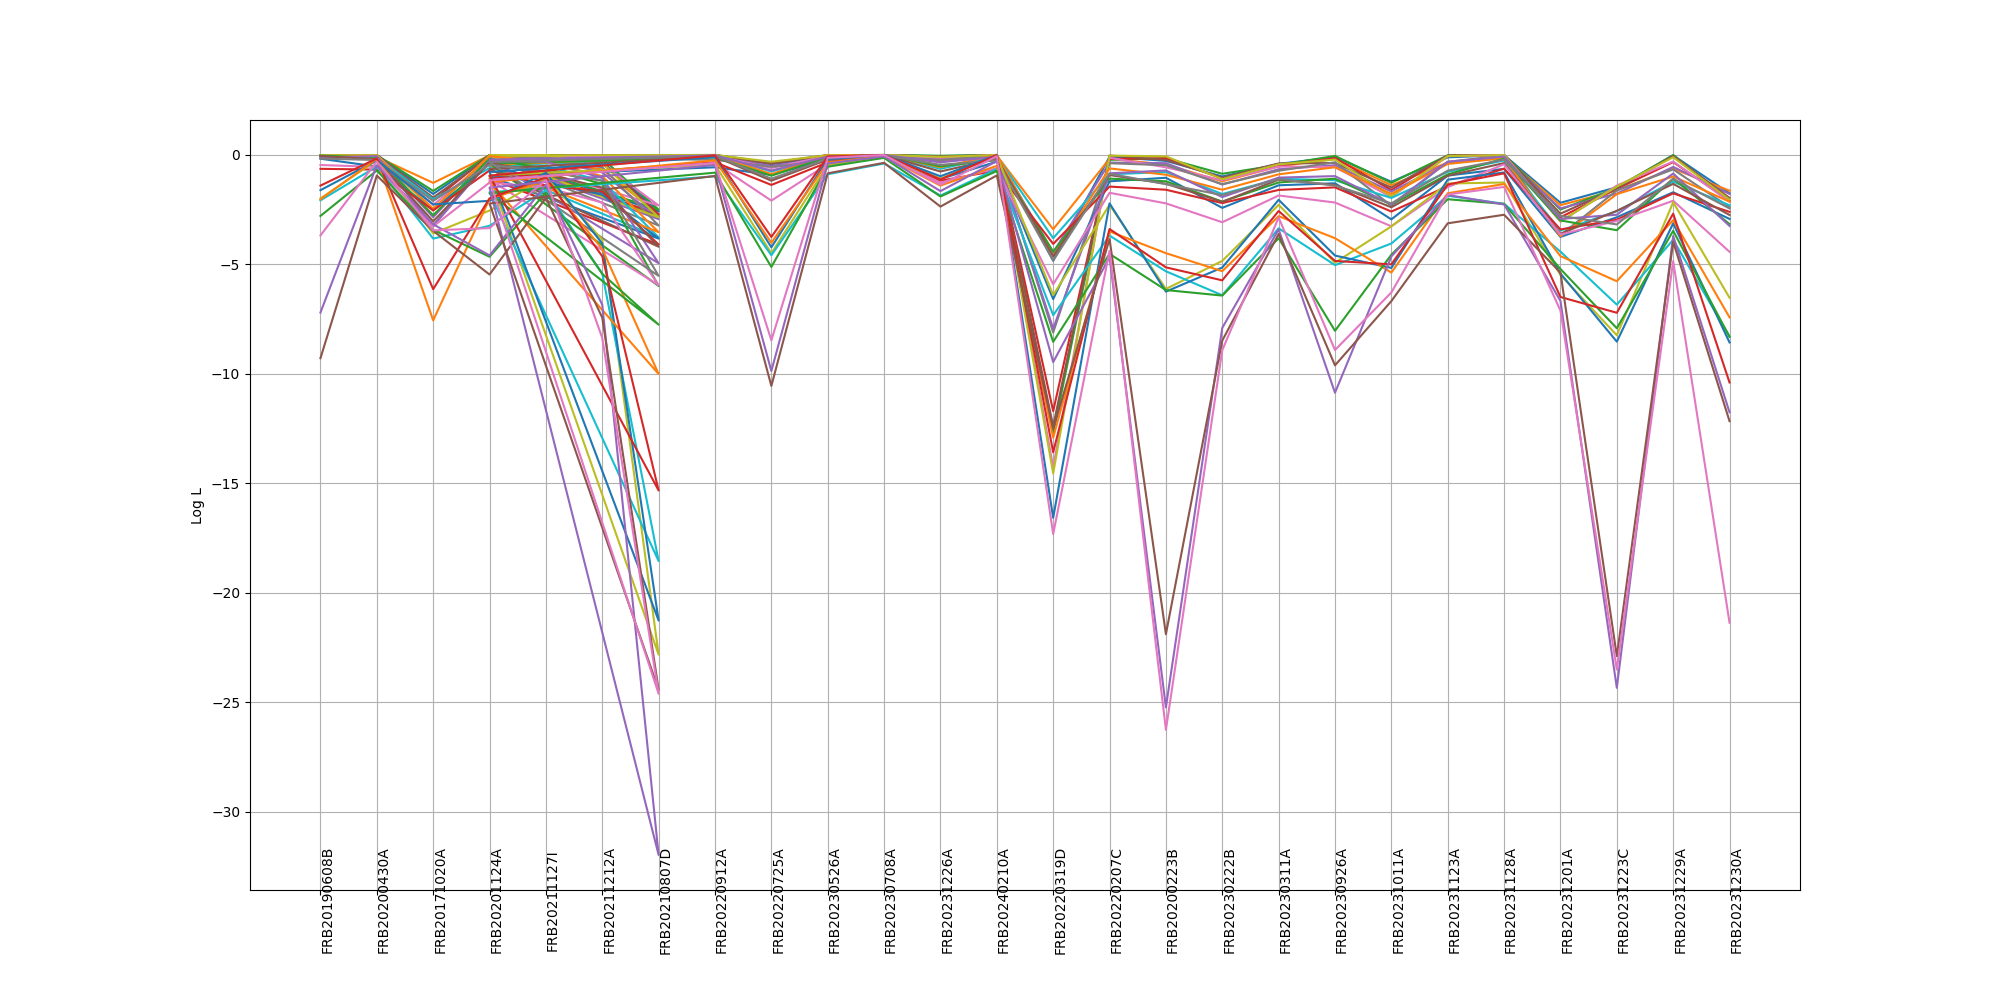

In [70]:
plt.figure(figsize = (20,10))
for iimodel in range(3):
    for jjz in range(3):
        for kkb in range(3):
            plt.plot(df.index,log_likelihoods_per_burst[iimodel,jjz,kkb,:])
plt.setp(plt.gca().get_xticklabels(), rotation=90, ha='center', rotation_mode='anchor')
plt.ylabel('Log L')
plt.grid(True)

In [89]:
df['DM_host_restframe']

name
FRB20190608B    182.377667
FRB20200430A    201.059705
FRB20171020A     18.538473
FRB20201124A    167.181472
FRB20211127I    109.309272
FRB20211212A     81.015180
FRB20210807D    -59.182176
FRB20201124A    169.636840
FRB20220912A    193.616747
FRB20220725A     76.302517
FRB20230526A    183.469296
FRB20230708A    282.087398
FRB20231226A    152.324698
FRB20240210A    206.400564
FRB20220319D    -78.347729
FRB20220207C    116.622641
FRB20200223B     77.239932
FRB20230222B     31.918165
FRB20230311A     86.947102
FRB20230926A     84.391005
FRB20231011A     16.414391
FRB20231123A    125.863186
FRB20231128A    204.692981
FRB20231201A    -37.508405
FRB20231223C     -4.223794
FRB20231229A     93.625650
FRB20231230A     13.887842
Name: DM_host_restframe, dtype: float64

In [87]:
np.sum(fake_logl)

np.float64(-9.387322935743697)

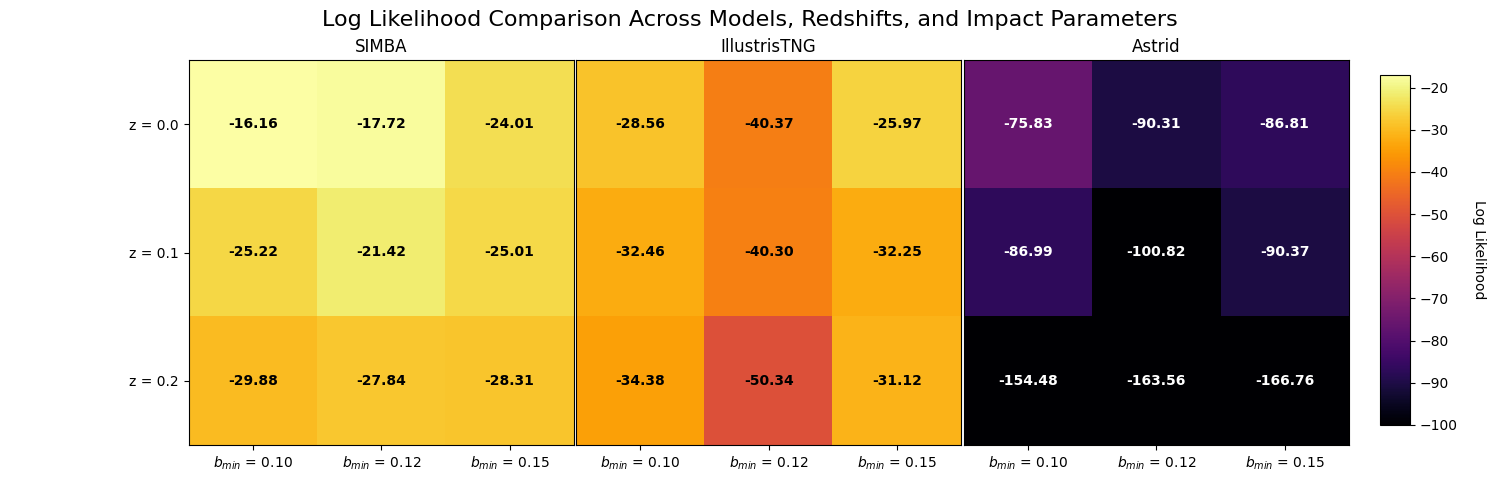

In [71]:
keep = np.array([name not in ['FRB20210807D'] for name in df.index])
ll = np.sum(log_likelihoods_per_burst[...,keep],axis = -1)
plot_fig(ll, out_file = os.path.join(ROOT_PATH,'figures/model_selection.pdf'))

In [97]:
np.sum(fake_logl.values[keep])

np.float64(-7.524320166067508)

In [91]:
fake_results = results.copy()
fake_results['weighted_mean'] = np.zeros_like(fake_results['weighted_mean'])

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

# Generate sample log likelihood data (replace this with your actual data)
# Shape: (3 models, 3 redshifts, 3 impact parameters)

def plot_fig(log_likelihoods,out_file):
    # Define labels
    model_names = ['SIMBA', 'IllustrisTNG', 'Astrid']
    redshifts = ['z = 0.0', 'z = 0.1', 'z = 0.2']
    impact_params = [r'$b_{min}$ = 0.10', r'$b_{min}$ = 0.12', r'$b_{min}$ = 0.15']
    
    # Create figure with 3 subplots (one for each model)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Log Likelihood Comparison Across Models, Redshifts, and Impact Parameters', fontsize=16)
    
    # Find global min and max for consistent color scale
    vmin = -100 #np.min(log_likelihoods)
    vmax = -17 # np.max(log_likelihoods)
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    # Loop through models (subplots)
    for model_idx, ax in enumerate(axes):
        # Get data for this model
        model_data = log_likelihoods[model_idx]
        
        # Create imshow plot
        im = ax.imshow(model_data, cmap='inferno', norm=norm)
        
        # Add value text to each cell
        for z_idx in range(3):  # redshift index
            for b_idx in range(3):  # impact parameter index
                value = model_data[z_idx, b_idx]
                ax.text(b_idx, z_idx, f'{value:.2f}', 
                        ha='center', va='center', 
                        color='white' if value < (vmin + vmax) / 2 else 'black',
                        fontweight='bold')
        
        # Set title and labels
        ax.set_title(model_names[model_idx])
        ax.set_xticks(np.arange(3))
        ax.set_yticks(np.arange(3))
        ax.set_xticklabels(impact_params)
        
        # Rotate x-axis labels for better readability
        plt.setp(ax.get_xticklabels(), rotation=0, ha='center', rotation_mode='anchor')
        
        # Add grid to make cells more visible
        ax.grid(False)
    axes[0].set_yticklabels(redshifts)
    axes[1].set_yticks([])
    axes[2].set_yticks([])
    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Log Likelihood', rotation=270, labelpad=20)
    
    # Adjust layout
    #plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(wspace = 0,hspace = 0)
    plt.savefig(out_file,dpi = 110,bbox_inches= 'tight')
